# **Building Permit Analytics for Florida**

© 2025 Carl Legros, Joao Vitor Jeronimo, Rose Kerlande Jeanmary, Pablo Olmedo  
Licensed under the MIT License.  

## Attribution
This project was developed collaboratively by
**Carl Legros**, **Joao Vitor Jeronimo**, **Rose Kerlande Jeanmary**, and **Pablo Olmedo**.  
Please credit all contributors when reusing or sharing this work.

<br></br>

# Problem Statement

Building permits serve as vital indicators of urban growth, regulatory oversight, and economic activity. They capture the dynamics of how cities expand, adapt, and allocate resources, offering a window into both the challenges and opportunities of development. This project leverages municipal permit data to classify projects as Residential or Commercial, with the broader aim of uncovering meaningful trends in construction activity, regulatory processes, and cost structures.
<br></br>

The analysis is guided by three core objectives:

1. Exploration of patterns in construction activity, approval workflows, and cost dynamics.

2. Application of predictive models to classify permits, evaluate their performance, and forecast average permit cost in the next 5 years.

3. Interpretation of results to identify influential features, and connect both classification and cost-forecast insights to practical implications for city planning and resource allocation.
<br></br>


In [81]:
# import libraries
!pip install catboost

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm


from catboost import CatBoostClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler,  OneHotEncoder, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import mean_squared_error, r2_score
from prophet import Prophet

##**Data Preprocessing**

In [82]:
# Load dataset
file_id = "1D14RpF5EQZ1bj_7LAWEpcUqv2GhMSKVJ"
url = f"https://drive.google.com/uc?export=download&id={file_id}"
df = pd.read_csv(url)
print(df.head())

   ID  AdditionSQFT ApplicationNumber BuildingFinalLastInspDate  \
0   3           0.0        BD12000118                       NaN   
1   6           0.0        BD12000212           9/18/2014 14:21   
2   9           0.0        BD12000375                       NaN   
3   1           0.0        BD12000077                       NaN   
4  22           0.0        BD12000846                       NaN   

   BuildingFinalLastInspResult BuildingPermitStatusDescription  \
0                          NaN                          Active   
1                          NaN                          Active   
2                          NaN                         Expired   
3                          NaN                          Active   
4                          NaN                         Revoked   

      BuildingPermitStatusReasonDescription Certificatecode Certificatedate  \
0  Permit is Active. Ready for Inspections.             NaN             NaN   
1  Permit is Active. Ready for Inspections

In [83]:
# Check feature types
print(df.dtypes)

ID                                         int64
AdditionSQFT                             float64
ApplicationNumber                         object
BuildingFinalLastInspDate                 object
BuildingFinalLastInspResult              float64
BuildingPermitStatusDescription           object
BuildingPermitStatusReasonDescription     object
Certificatecode                           object
Certificatedate                           object
CompanyAddress                            object
CompanyCity                               object
CompanyName                               object
CompanyZip                               float64
DaysInCity                                object
DaysInCityNumeric                        float64
DeliveryAddress                           object
FirstSubmissionDate                       object
FolioNumber                              float64
IsPermitFinal                               bool
IsPrivateProvider                           bool
IssuedDate          

In [84]:
# Dataset dimension
print(df.shape)

(69976, 41)


In [85]:
# Check missing values
print(df.isnull().sum())

ID                                           0
AdditionSQFT                              1741
ApplicationNumber                            0
BuildingFinalLastInspDate                58124
BuildingFinalLastInspResult              69976
BuildingPermitStatusDescription              0
BuildingPermitStatusReasonDescription        0
Certificatecode                          65008
Certificatedate                          65008
CompanyAddress                            2693
CompanyCity                               2693
CompanyName                               2693
CompanyZip                                2693
DaysInCity                               37825
DaysInCityNumeric                        37825
DeliveryAddress                              0
FirstSubmissionDate                      37817
FolioNumber                                  0
IsPermitFinal                                0
IsPrivateProvider                            0
IssuedDate                                  11
Latitude     

In [86]:
# Replace missing values with mode
df['IssuedDate'] = df['IssuedDate'].fillna(df['IssuedDate'].mode()[0])
df['PlanAcceptedDate'] = df['PlanAcceptedDate'].fillna(df['PlanAcceptedDate'].mode()[0])
df['Miami21Zone'] = df['Miami21Zone'].fillna(df['Miami21Zone'].mode()[0])
df['WorkItems'] = df['WorkItems'].fillna(df["WorkItems"].mode()[0])

# Replace missing values with median
df['AdditionSQFT'] = df['AdditionSQFT'].fillna(df['AdditionSQFT'].median())
df['TotalDaysInPlanReviewNumeric'] = df['TotalDaysInPlanReviewNumeric'].fillna(df['TotalDaysInPlanReviewNumeric'].median())
df['RemodelingCost'] = df['RemodelingCost'].fillna(df['RemodelingCost'].median())
df['RemSQFT'] = df['RemSQFT'].fillna(df['RemSQFT'].median())
df['TotalSQFT'] = df['TotalSQFT'].fillna(df['TotalSQFT'].median())
df['RequiredCertificate'] = df['RequiredCertificate'].fillna("Not Required")
df['TotalCost'] = df['TotalCost'].fillna(df['TotalCost'].median())

# Fill categorical features with 'Unknown'
for col in ['CompanyAddress', 'CompanyCity', 'CompanyName', 'CompanyZip']:
    df[col] = df[col].fillna("Unknown")

# Drop columns with excessive missing values
drop_cols = ['BuildingFinalLastInspDate', 'BuildingFinalLastInspResult',
    'Certificatecode', 'Certificatedate',
    'DaysInCity', 'DaysInCityNumeric',
    'FirstSubmissionDate', 'NewAdditionCost']
df.drop(columns=drop_cols, inplace=True)

# Drop additional column
df.drop(columns=["TotalDaysInPlanReview"], inplace=True)

In [87]:
# Remove duplicates
df.drop_duplicates(inplace=True)

In [88]:
# Verify elements
df['ScopeofWork'].unique()

array(['ELECTRICAL', 'REMODELING/REPAIRS', 'TREE PERMIT',
       'BUILDING ROOFING', 'PLUMBING', 'NEW CONSTRUCTION', 'SIGN',
       'MECHANICAL', '40 YEAR AND OLDER RECERTIFICATION',
       'ADDITION AND REMODELING', 'FIRE', 'ELEVATOR', 'SPECIAL EVENTS',
       'DEMOLITION', 'PHASED PERMIT', 'ANNUAL FACILITY', 'BOILER',
       'COOKIE CUTTER', 'PLUMBING GAS', 'TEMPORARY EVENTS', 'LANDSCAPING'],
      dtype=object)

In [89]:
# Function that reduce ScopeofWork elements to 4
def Category(ScopeofWork):
  if (ScopeofWork =="REMODELING/REPAIRS") or (ScopeofWork=="BUILDING ROOFING") or (ScopeofWork=="NEW CONSTRUCTION"):
   return "Construction"
  elif ScopeofWork== "SIGN":
   return "Marketing"
  elif ((ScopeofWork== "PLUMBING") or (ScopeofWork== "ELECTRICAL") or (ScopeofWork=="MECHANICAL") ) :
   return "Maintenance"
  else:
   return "Attention"

In [90]:
# Create Category feature by apllying new function
df['Category'] = df['ScopeofWork'].apply(Category)

In [91]:
# Check elements
df['Category'].unique()

array(['Maintenance', 'Construction', 'Attention', 'Marketing'],
      dtype=object)

In [92]:
# Recheck for missing values
print(df.isnull().sum())
print()
print("Data Cleaning Successful!")

ID                                       0
AdditionSQFT                             0
ApplicationNumber                        0
BuildingPermitStatusDescription          0
BuildingPermitStatusReasonDescription    0
CompanyAddress                           0
CompanyCity                              0
CompanyName                              0
CompanyZip                               0
DeliveryAddress                          0
FolioNumber                              0
IsPermitFinal                            0
IsPrivateProvider                        0
IssuedDate                               0
Latitude                                 0
Longitude                                0
Miami21Zone                              0
PermitNumber                             0
PlanAcceptedDate                         0
PlanCreatedDate                          0
ProcessNumber                            0
PropertyType                             0
RemodelingCost                           0
RemSQFT    

In [93]:
## New dataset dimension
print("\nFinal dimension of dataset after cleaning:\n",df.shape)


Final dimension of dataset after cleaning:
 (69976, 33)


---

# **Exploratory Analysis**

### Summary Statistics

In [94]:
df[['TotalSQFT','TotalCost','RemodelingCost','RemSQFT']].describe()

,TotalSQFT,TotalCost,RemodelingCost,RemSQFT
count,6.997600e+04,6.997600e+04,6.997600e+04,69976.000000
mean,3.779384e+03,1.580480e+05,2.141098e+04,668.064636
std,4.618348e+04,3.079704e+06,2.976704e+05,5154.159788
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000
25%,0.000000e+00,3.000000e+03,0.000000e+00,0.000000
50%,0.000000e+00,8.500000e+03,0.000000e+00,0.000000
75%,0.000000e+00,2.380000e+04,0.000000e+00,0.000000
max,1.904889e+06,3.335075e+08,2.922744e+07,224000.000000


### Comment:
The summary statistics reveals a high variance across cost and square footage feaures, with extreme outliers inflating the averages. These outliers represent multimillion‑dollar projects that heavily skew the overall distribution. It is also notable that most permits show no remodeling, underscoring that only a small fraction of projects drive large scale cost or square footage.

<br></br>

### Correlation Matrix

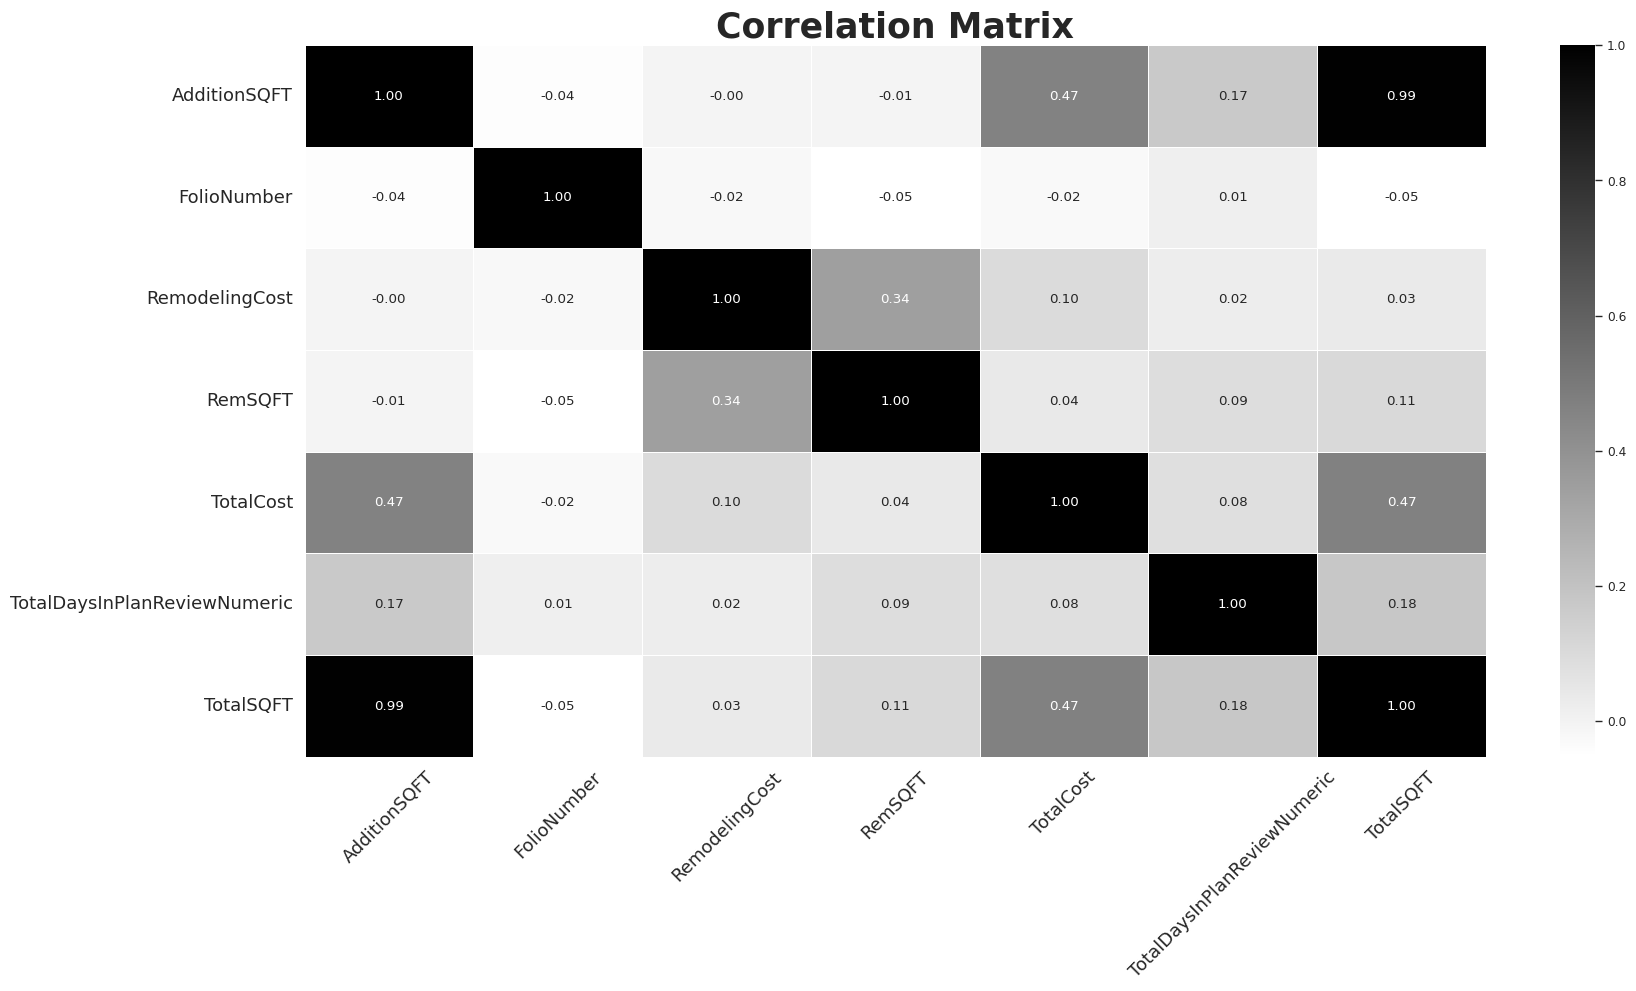

In [95]:
# Select all numeric columns
num_cols = df.select_dtypes(include=['number']).columns

# Drop irrelevant numeric features
filtered_num = df[num_cols].drop(columns=['Latitude','Longitude','ID'])

# Correlation object
correlation_matrix = filtered_num.corr()

# Plot correlation matrix
plt.figure(figsize=(18,10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="binary", linewidth=0.7)
plt.title("Correlation Matrix", fontsize=25,weight='bold')
plt.xticks(rotation=45,fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

### Comment:
The correlation matrix revealed a near-perfect relationship (0.99) between `AdditionSQFT` and `TotalSQFT`, indicating multicollinearity. To improve the model's stability and predictive power, we removed `AdditionSQFT`, since `TotalSQFT` offers a more comprehensive measure of property size.

<br></br>

### Histogram

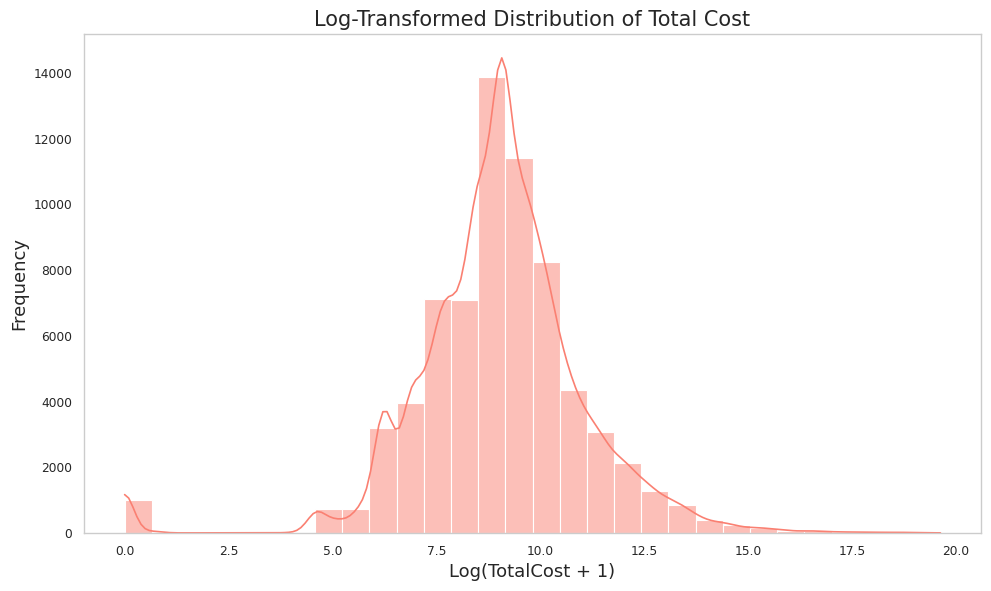

In [96]:
# Log-transformed total cost histogram
plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
sns.set_context("paper")
sns.histplot(np.log1p(df['TotalCost']), bins=30, kde=True, color='salmon')
plt.title('Log-Transformed Distribution of Total Cost',fontsize=15)
plt.xlabel('Log(TotalCost + 1)', fontsize=13)
plt.ylabel('Frequency',fontsize=13)
plt.tight_layout()
plt.grid(True, color='white')
plt.show()

### Comment:
* The log-transformation of total cost is close to a normal distribution, but is still right-skewed.
* This transformation helps normalize the data for modeling, especially for algorithms sensitive to skewness like Logistic Regression.

<br></br>

### Barplot

/tmp/ipython-input-2223920247.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_cost_permit.values, y=mean_cost_permit.index, palette='summer')


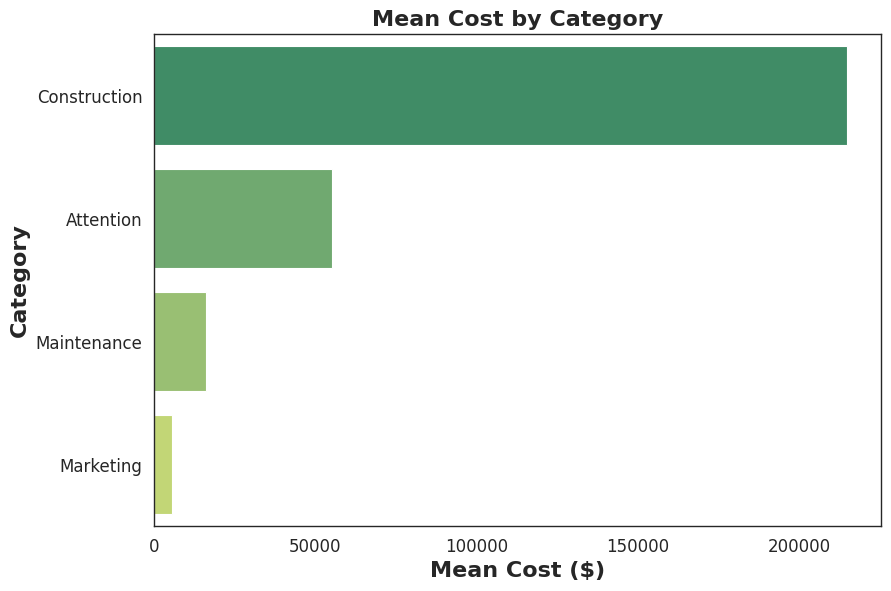

In [97]:
# Calculate the mean cost by category
mean_cost_permit = df.groupby('Category')['TotalCost'].mean().sort_values(ascending=False)

# Plot mean cost barplot
sns.set_style("white")
sns.set_context("paper")
plt.figure(figsize=(9,6))
sns.barplot(x=mean_cost_permit.values, y=mean_cost_permit.index, palette='summer')
plt.title('Mean Cost by Category', weight='bold', fontsize=16)
plt.xlabel('Mean Cost ($)', weight='bold', fontsize=16)
plt.ylabel('Category',fontsize=16, weight='bold')
plt.yticks(rotation=0,fontsize=12)
plt.xticks(fontsize=12)
plt.tight_layout()
plt.show()

### Comment:
* Construction permits dominate the overall spending.
* Attention and Maintenance permit costs are at a moderate range, reflecting corrective work.
* Marketing permits have have minimal influence on permit expenditures.

/tmp/ipython-input-2032452622.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=sum_cost_per_property.index, y=sum_cost_per_property.values, palette=['yellow','navy'],edgecolor='black')


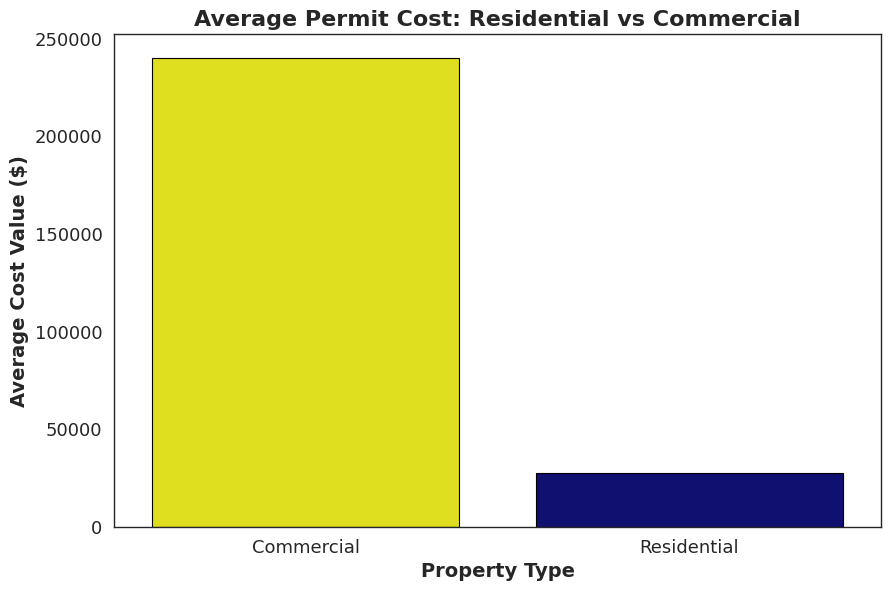

In [98]:
# Calculate average cost by property type
sum_cost_per_property= df.groupby('PropertyType')['TotalCost'].mean()

# Plot property type
plt.figure(figsize=(9,6))
ax = sns.barplot(x=sum_cost_per_property.index, y=sum_cost_per_property.values, palette=['yellow','navy'],edgecolor='black')
plt.title('Average Permit Cost: Residential vs Commercial', fontsize=16,weight='bold')
plt.ylabel('Average Cost Value ($)', fontsize=14,weight='bold')
plt.xlabel('Property Type', fontsize=14,weight='bold')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tight_layout()
plt.show()

### Comment:
This disparity suggests that commercial projects are typically larger in scale, more complex, and possibly subject to higher regulatory or material demands.

/tmp/ipython-input-283060322.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=prop_counts.index, y=prop_counts.values, palette=['brown', 'orange'], edgecolor='white')


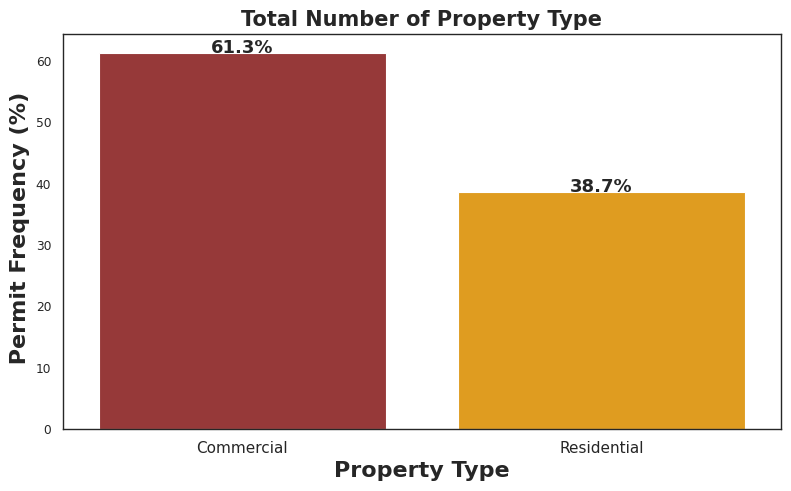

In [99]:
#  property type percentage frequency
prop_counts = df['PropertyType'].value_counts(normalize=True) *100

# Barplot
plt.figure(figsize=(8, 5))
ax = sns.barplot(x=prop_counts.index, y=prop_counts.values, palette=['brown', 'orange'], edgecolor='white')
plt.title('Total Number of Property Type', fontsize=15, weight='bold')
# Annotate percentages
for i, val in enumerate(prop_counts.values):
    ax.text(i, val, f"{val:.1f}%", ha='center', fontsize=13,weight='bold')
plt.xlabel('Property Type', fontsize=16,weight='bold')
plt.ylabel(' Permit Frequency (%)', fontsize=16, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.grid(True,color='white')
plt.show()

### Comment:
* Commercial properties account for 61.3% of all permits, indicating a strong emphasis on business-related development and infrastructure in Florida.

* Residential permits make up 38.7%, suggesting a smaller share of activity focused on housing.

/tmp/ipython-input-1771889142.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax= sns.barplot(x=category_pct.index, y=category_pct.values, palette='GnBu_r',edgecolor='white')


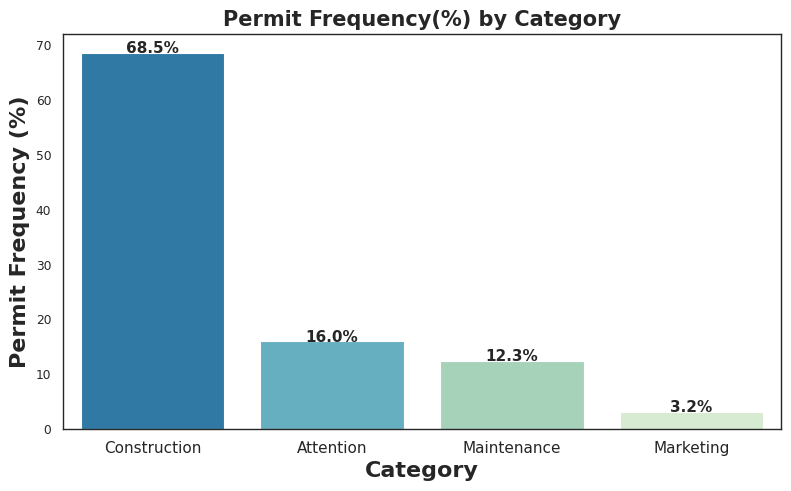

In [100]:
#  property type percentage
category_pct = df['Category'].value_counts(normalize=True) *100

# Barplot
plt.figure(figsize=(8, 5))
ax= sns.barplot(x=category_pct.index, y=category_pct.values, palette='GnBu_r',edgecolor='white')
for i, val in enumerate(category_pct.values):
    ax.text(i, val,f"{val:.1f}%", ha='center', fontsize=11,weight='bold')
plt.title('Permit Frequency(%) by Category', fontsize=15, weight='bold')
plt.xlabel('Category', fontsize=16,weight='bold')
plt.ylabel('Permit Frequency (%)', fontsize=16, weight='bold')
plt.xticks(rotation=0, fontsize=11)
plt.tight_layout()
plt.grid(True,color='white')
plt.show()

### Comment:
* This distribution suggests that the majority of permitting activity is driven by structural development and expansion.
* Operational and promotional activities represent a much smaller share.
* The imbalance between Construction and the other categories might reflect regulatory priorities and sustained investments in structural development, key drivers of urban growth and economic activity.

<br></br>

### Boxplot

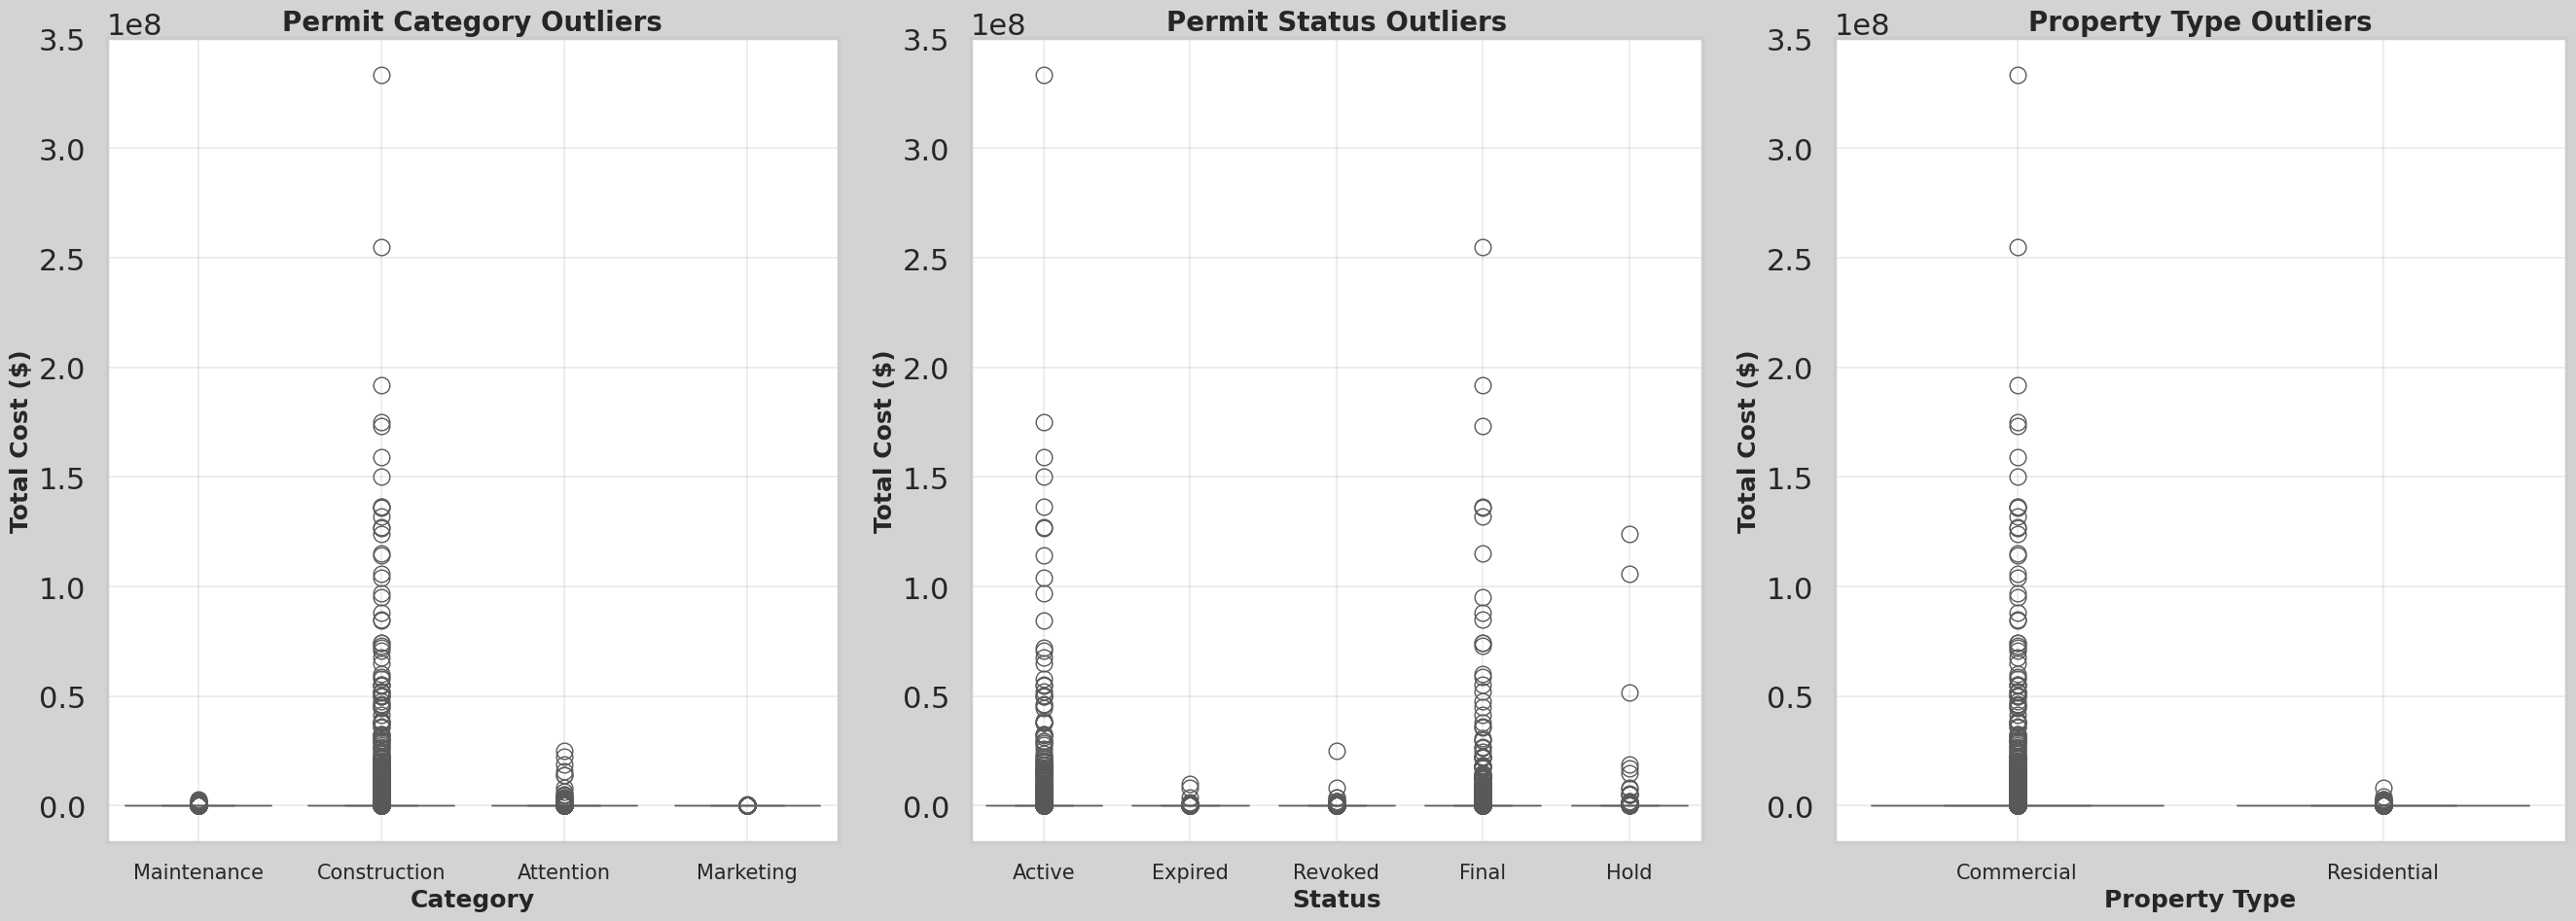

In [101]:
# Set style and context
sns.set_style("whitegrid")
sns.set_context("poster")

# Create subplot grid
fig, axes = plt.subplots(1, 3, figsize=(27, 10))
fig.patch.set_facecolor('lightgrey')

# Boxplot 1: Category
axes[0].set_facecolor('white')
sns.boxplot(data=df, x='Category', y='TotalCost', palette='Set2', hue='Category',legend=False,ax=axes[0])
axes[0].set_title('Permit Category Outliers', fontsize=20, weight='bold')
axes[0].set_xlabel("Category", fontsize=18, weight='bold')
axes[0].set_ylabel("Total Cost ($)", fontsize=18, weight='bold')
axes[0].grid(True, color='black', linewidth=0.1)
axes[0].tick_params(axis='x',labelsize=15)

# Boxplot 2: Permit Status
axes[1].set_facecolor('white')
sns.boxplot(data=df, x='BuildingPermitStatusDescription', y='TotalCost', palette='Set2', hue='BuildingPermitStatusDescription',legend=False, ax=axes[1])
axes[1].set_title('Permit Status Outliers', fontsize=20, weight='bold')
axes[1].set_xlabel("Status", fontsize=18, weight='bold')
axes[1].set_ylabel("Total Cost ($)", fontsize=18, weight='bold')
axes[1].grid(True, color='black', linewidth=0.1)
axes[1].tick_params(axis='x',labelsize=15)


# Boxplot 3: Property Type
axes[2].set_facecolor('white')
sns.boxplot(data=df, x='PropertyType', y='TotalCost', palette='Set2',hue='PropertyType',legend=False, ax=axes[2])
axes[2].set_title('Property Type Outliers', fontsize=20, weight='bold')
axes[2].set_xlabel("Property Type", fontsize=18, weight='bold')
axes[2].set_ylabel("Total Cost ($)", fontsize=18, weight='bold')
axes[2].grid(True, color='black', linewidth=0.1)
axes[2].tick_params(axis='x',labelsize=15)

plt.tight_layout()
plt.show()


### Comment:
1. Construction permits dominate in cost outliers, with several projects exceeding 300 million dollars; a confirmation that large-scale developments are concentrated in this category.

2. Active and Final statuses show the highest cost outliers. This suggest that high-value permits tend to be finalized or remain in progress.

3. Commercial properties show much extreme costs than Residential ones, making them more capital-intensive in Florida.

<br></br>

### Donutplot

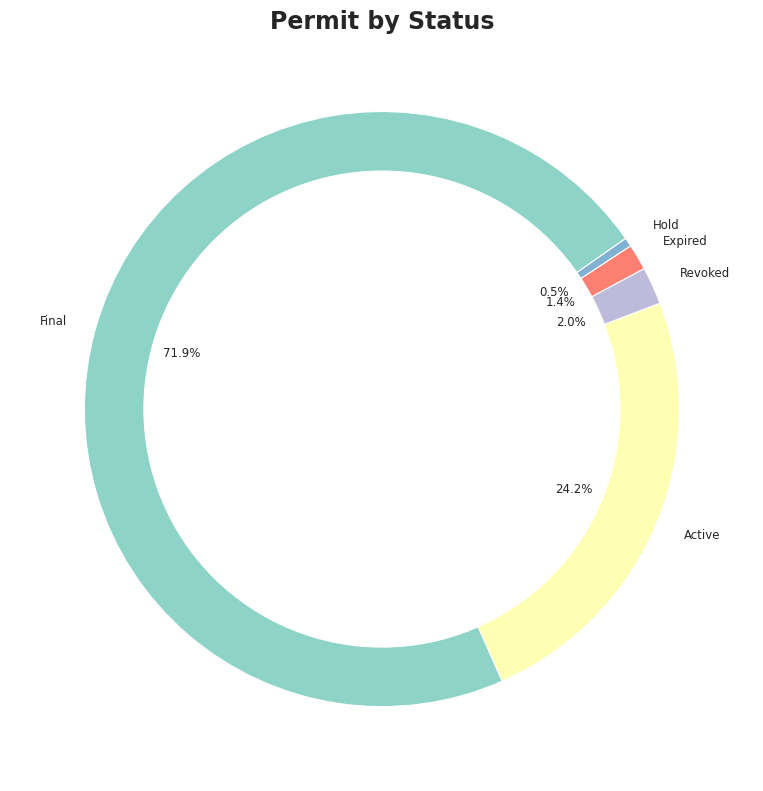

In [102]:
# Number of permits per status
status_count = df['BuildingPermitStatusDescription'].value_counts()

# Donut chart
sns.set_context("paper")
plt.figure(figsize=(9,8))
plt.pie(status_count.values, labels=status_count.index, autopct='%1.1f%%',startangle=35, pctdistance=0.7,
    colors=sns.color_palette('Set3', len(status_count)),
                textprops={'fontsize': 8.5})


# Add circle in the center to make donutplot
centre_circle = plt.Circle((0,0),0.80,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)
plt.title('Permit by Status', weight='bold', fontsize=17)
plt.tight_layout()
plt.show()

### Comment:
This chart indicates that most permites in Florida have already been finalized, with a smaller but significant portion active, and only small fractions of permits are being revoked, expired, or on hold. **In terms of permitting cycle, Florida's buidings projects are largely finalized.**

<br></br>

### Scatterplots

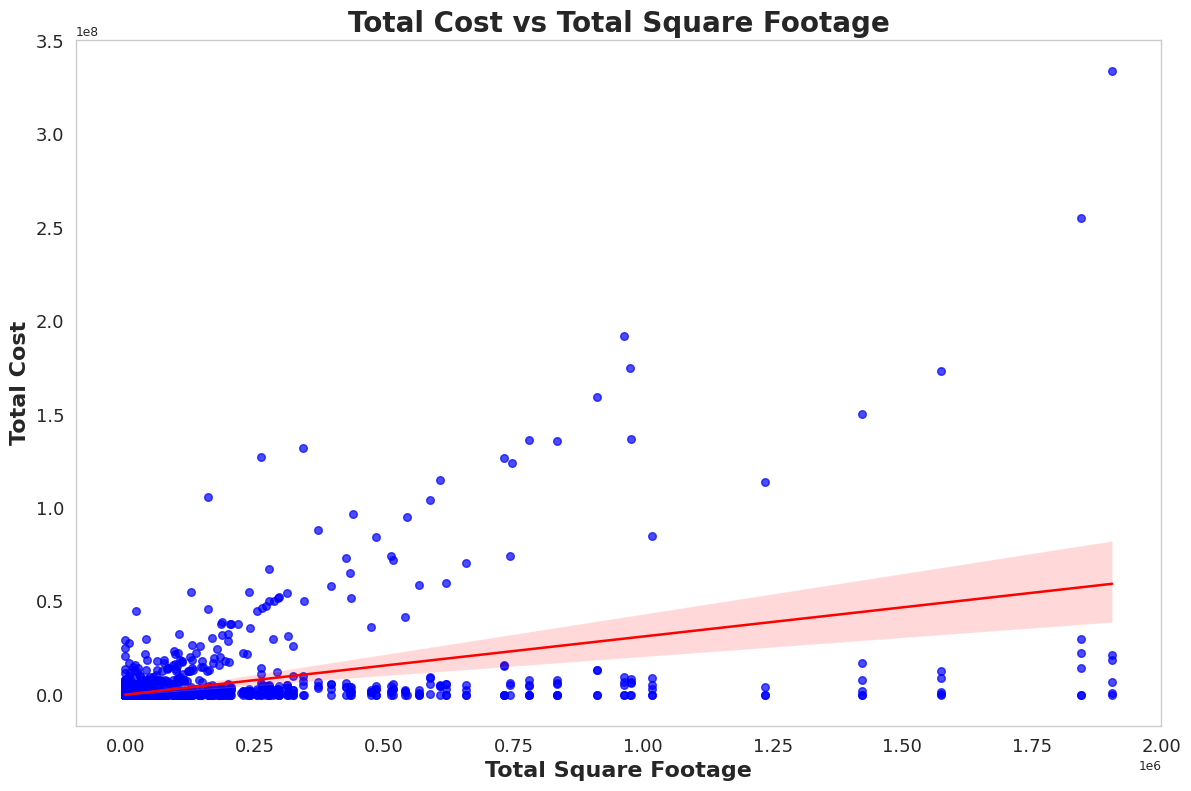

In [103]:
# TotalCost vs TotalSQFT scatterplot
sns.set_context("paper")
plt.figure(figsize=(12, 8))
sns.regplot(x='TotalSQFT', y='TotalCost', scatter_kws={'color':'blue','s': 30, 'alpha': 0.7},
            line_kws={'color': 'red'},data=df)
plt.title('Total Cost vs Total Square Footage', fontsize=20, weight='bold')
plt.xlabel('Total Square Footage', fontsize=16, weight='bold')
plt.ylabel('Total Cost', fontsize=16, weight='bold')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, color='white')
plt.tight_layout()
plt.show()

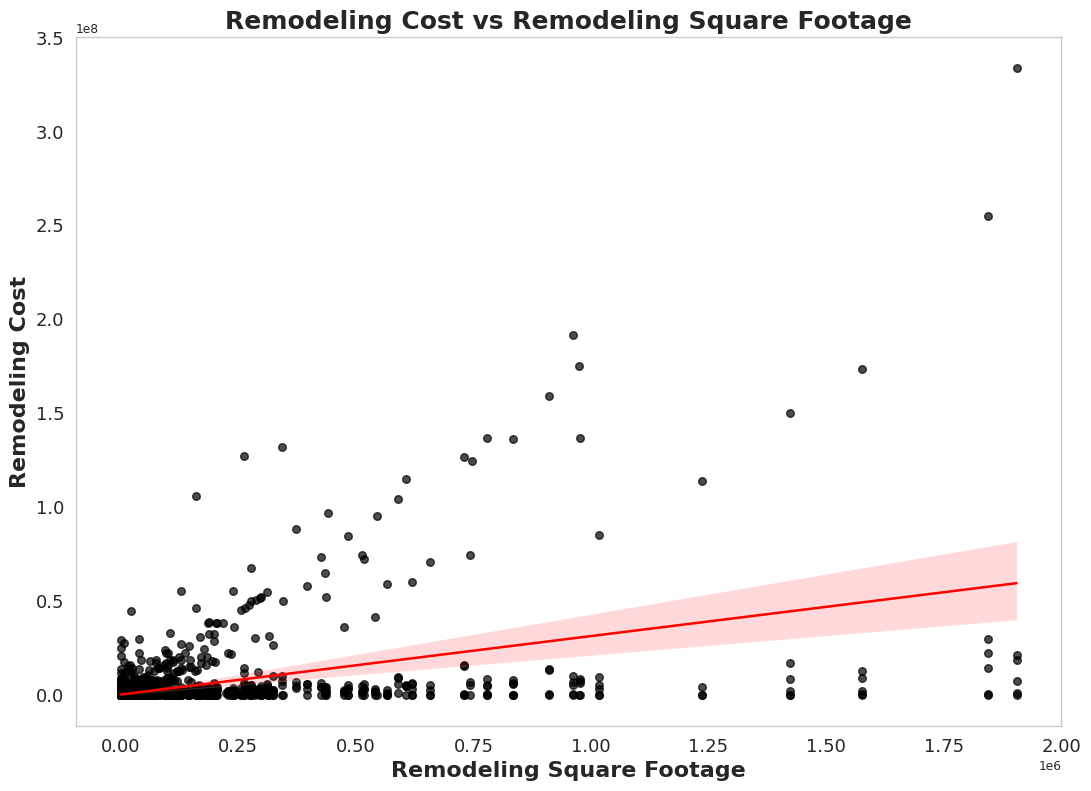

In [104]:
# RemodelingCost vs RemSQFT scatterplot
sns.set_context("paper")
plt.figure(figsize=(11, 8))
sns.regplot(x='TotalSQFT', y='TotalCost', scatter_kws={'color':'black','s': 30, 'alpha': 0.7},
            line_kws={'color': 'red'},data=df)
plt.title('Remodeling Cost vs Remodeling Square Footage', fontsize=18, weight='bold')
plt.xlabel('Remodeling Square Footage', fontsize=16, weight='bold')
plt.ylabel('Remodeling Cost', fontsize=16, weight='bold')
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.grid(True, color='white')
plt.tight_layout()
plt.show()

### Comment:
Both scatter plots show a clear positive correlation between square footage and cost, confirming that larger projects tend to be more expensive.

---

# **Model Development**

### Feature Enginnering

In [105]:
# Create Ratios for scale adjustments
df['CostPerSQFT'] = df['TotalCost'] / (df['TotalSQFT'] + 1)
df['RemodelingRatio'] = df['RemodelingCost'] / (df['TotalCost'] + 1)

# For large scale projects
df['IsLarge'] = (df['TotalSQFT'] > df['TotalSQFT'].median()).astype(int)

# Transform raw features to log
df['LogCost'] = np.log1p(df['TotalCost'])
df['LogSQFT'] = np.log1p(df['TotalSQFT'])
df['LogRemodelingCost'] = np.log1p(df['RemodelingCost'])
df['LogRemSQFT'] = np.log1p(df['RemSQFT'])

# Interaction terms
df['Cost_Category'] = df['TotalCost'] * df['IsLarge']
df['RemodelingRatio_Large'] = df['RemodelingRatio'] * df['IsLarge']


<br></br>

### Logistic Regression

In [106]:
# Include relevant features
features = [
    "BuildingPermitStatusDescription", "Category",
    "LogSQFT",
     "LogRemodelingCost", "LogRemSQFT"
   ,"Miami21Zone","RequiredCertificate"
]

# Create target and predictors
target = "PropertyType"
X = df[features]
y = df[target]

# Separate numeric and categorical
numeric_features = ["LogSQFT", "LogRemodelingCost", "LogRemSQFT"]

categorical_features =["BuildingPermitStatusDescription","Category",
                        "Miami21Zone","RequiredCertificate"]

# Scale numeric features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_features])

# Encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = encoder.fit_transform(X[categorical_features])

# Combine numeric + categorical
X_processed = np.hstack([X_num_scaled, X_cat])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)

In [107]:
# Logistic Regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Results")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Results

Accuracy: 0.9422692197770791
              precision    recall  f1-score   support

  Commercial       0.93      0.97      0.95      8580
 Residential       0.96      0.89      0.92      5416

    accuracy                           0.94     13996
   macro avg       0.95      0.93      0.94     13996
weighted avg       0.94      0.94      0.94     13996



<br></br>

### Random Forest

In [108]:
# Create Ratios for scale adjustments
df['CostPerSQFT'] = df['TotalCost'] / (df['TotalSQFT'] + 1)
df['RemodelingRatio'] = df['RemodelingCost'] / (df['TotalCost'] + 1)

# For large scale projects
df['IsLarge'] = (df['TotalSQFT'] > df['TotalSQFT'].median()).astype(int)

# Transform raw features to log
df['LogCost'] = np.log1p(df['TotalCost'])
df['LogSQFT'] = np.log1p(df['TotalSQFT'])
df['LogRemodelingCost'] = np.log1p(df['RemodelingCost'])
df['LogRemSQFT'] = np.log1p(df['RemSQFT'])


# Include relevant features
features = ["BuildingPermitStatusDescription", "Category",
            "LogSQFT", "LogRemodelingCost", "LogRemSQFT",
     "Miami21Zone","RequiredCertificate"]

# Create target and predictors
target = "PropertyType"
X = df[features]
y = df[target]

# Separate numeric and categorical
numeric_features = ["LogSQFT",
    "LogRemodelingCost","LogRemSQFT"
]
categorical_features =["BuildingPermitStatusDescription","Category",
                        "Miami21Zone","RequiredCertificate"]

# Scale numeric features
scaler = StandardScaler()
X_num_scaled = scaler.fit_transform(X[numeric_features])

# Encode categorical features
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
X_cat = encoder.fit_transform(X[categorical_features])

# Combine numeric + categorical
X_processed = np.hstack([X_num_scaled, X_cat])

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y)

In [109]:
#  Random Forest model
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("\nRandom Forest Performance Results:")
print()
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))


Random Forest Performance Results:

Accuracy: 0.9444126893398114
              precision    recall  f1-score   support

  Commercial       0.95      0.96      0.95      8580
 Residential       0.94      0.92      0.93      5416

    accuracy                           0.94     13996
   macro avg       0.94      0.94      0.94     13996
weighted avg       0.94      0.94      0.94     13996



#### Confusion Matrix

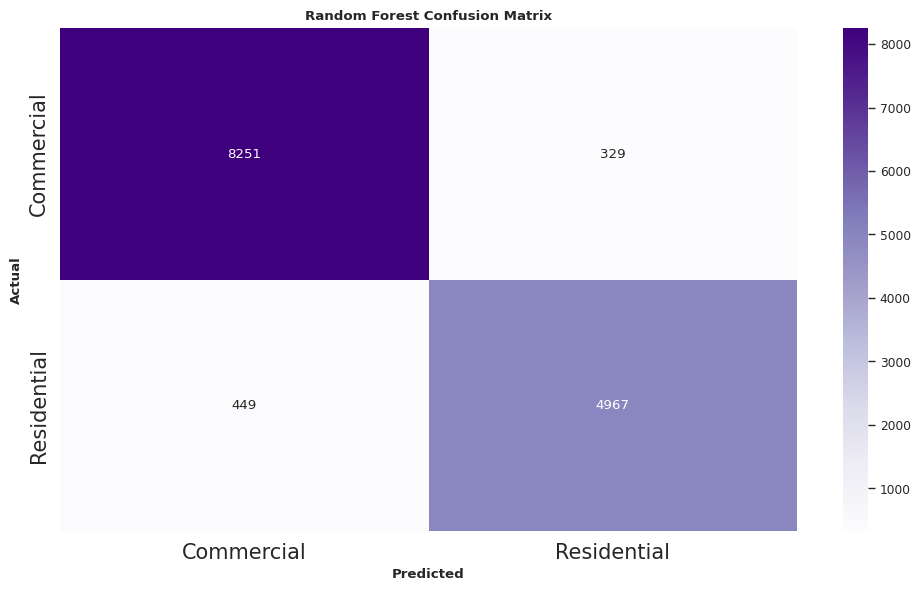

In [110]:
# Plot confusion matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(10, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Purples', xticklabels=['Commercial', 'Residential'], yticklabels=['Commercial', 'Residential'])
plt.title("Random Forest Confusion Matrix", weight='bold')
plt.xlabel("Predicted", weight='bold')
plt.ylabel("Actual", weight='bold')
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tight_layout()
plt.show()


### Comment:
* The Random Forest model correctly classified 8228 commercial (95% precision) and 4953 residential permits (93% preccision).
* Misclassifications are relatively small: only 463 residential permits misclassified as commercial, and only 352 commercial permits misclassified as residential.

#### Feature Importance

/tmp/ipython-input-160872987.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_features, x="Importance", y="Feature", palette='cool')


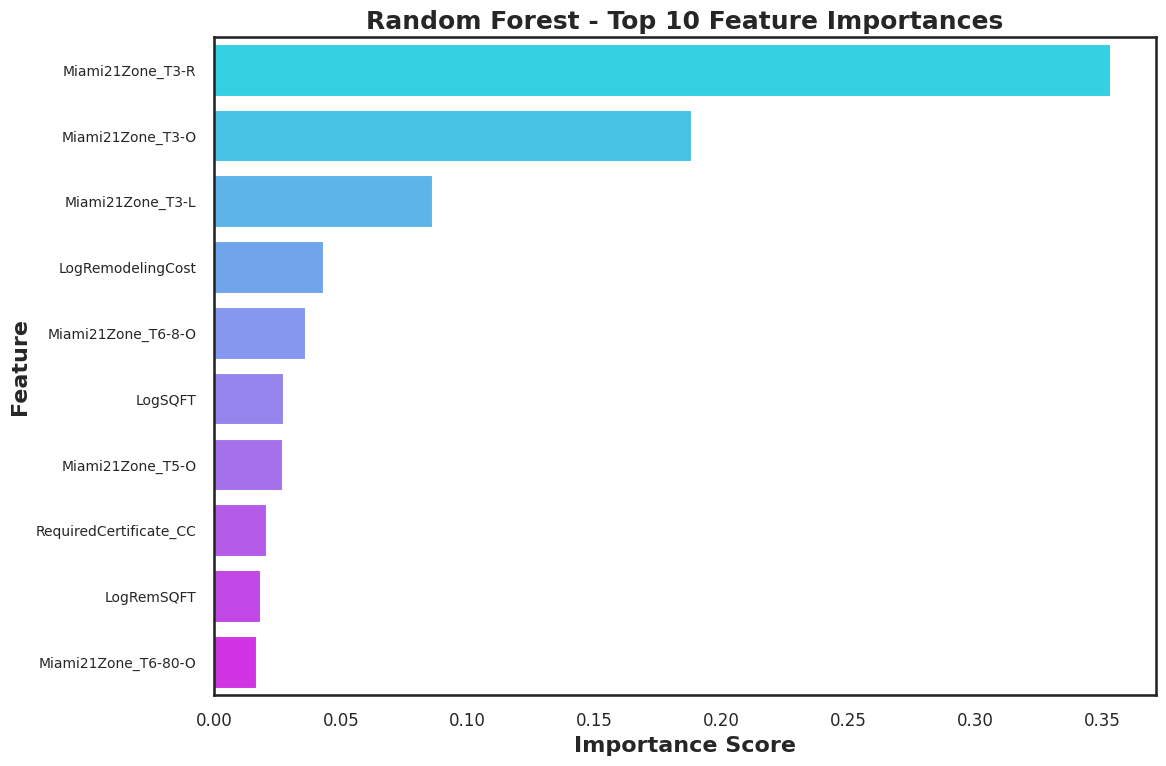

In [111]:
# Create importances features in Random Forest model
importances = rf.feature_importances_

# Combine with feature names
feature_names = encoder.get_feature_names_out(categorical_features)
feature_names = numeric_features + feature_names.tolist()

# Create data frame
rf_importance_df = pd.DataFrame({'Feature': feature_names,
                                 'Importance': importances
})

# Sort and select top 10 features
top_features = rf_importance_df.sort_values(by="Importance", ascending=False).head(10)

# Set style
sns.set_style("white")
sns.set_context("talk")

# Create horizontal barplot
plt.figure(figsize=(12, 8))
sns.barplot(data=top_features, x="Importance", y="Feature", palette='cool')
plt.title("Random Forest - Top 10 Feature Importances", fontsize=18, weight='bold')
plt.xlabel("Importance Score", fontsize=16, weight='bold')
plt.ylabel("Feature", fontsize=16,weight='bold')
plt.xticks(fontsize=12)
plt.yticks(fontsize=10, rotation=0)
plt.tight_layout()
plt.show()


**Zoning codes (`Miami21Zone`) are the dominant drivers of property type classification**

<br></br>

### XGBoost

In [112]:


# Encode target
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Model
xgb_clf = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    tree_method="hist",
    random_state=42
)

# Fit
xgb_clf.fit(X_train, y_train)

# Predict
xgb_pred = xgb_clf.predict(X_test)

# Evaluate
print("XGBoost Accuracy:", accuracy_score(y_test, xgb_pred))
print(classification_report(y_test, xgb_pred, target_names=le.classes_))


XGBoost Accuracy: 0.9454129751357531
              precision    recall  f1-score   support

  Commercial       0.94      0.97      0.96      8580
 Residential       0.95      0.90      0.93      5416

    accuracy                           0.95     13996
   macro avg       0.95      0.94      0.94     13996
weighted avg       0.95      0.95      0.95     13996



<br></br>

### CatBoost

In [113]:
cat_clf = CatBoostClassifier(
    iterations=400,
    learning_rate=0.05,
    depth=6,
    loss_function="MultiClass",
    verbose=False,
    random_state=42
)

cat_clf.fit(X_train, y_train)
cat_pred = cat_clf.predict(X_test)

print("CatBoost Accuracy:", accuracy_score(y_test, cat_pred))
print(classification_report(y_test, cat_pred))


CatBoost Accuracy: 0.9445555873106601
              precision    recall  f1-score   support

           0       0.94      0.97      0.96      8580
           1       0.95      0.90      0.93      5416

    accuracy                           0.94     13996
   macro avg       0.95      0.94      0.94     13996
weighted avg       0.94      0.94      0.94     13996



## XGBoost as the recommended model:
* It handles large tabular datasets extremely well
* Captures non-linear interactions in zoning, categories, and square feet better
* Has the best recall for Commercial permits, meaning the model correctly identified 97% of the actual Commercial permits in the dataset.



---



# **Forecasting Permit Cost**

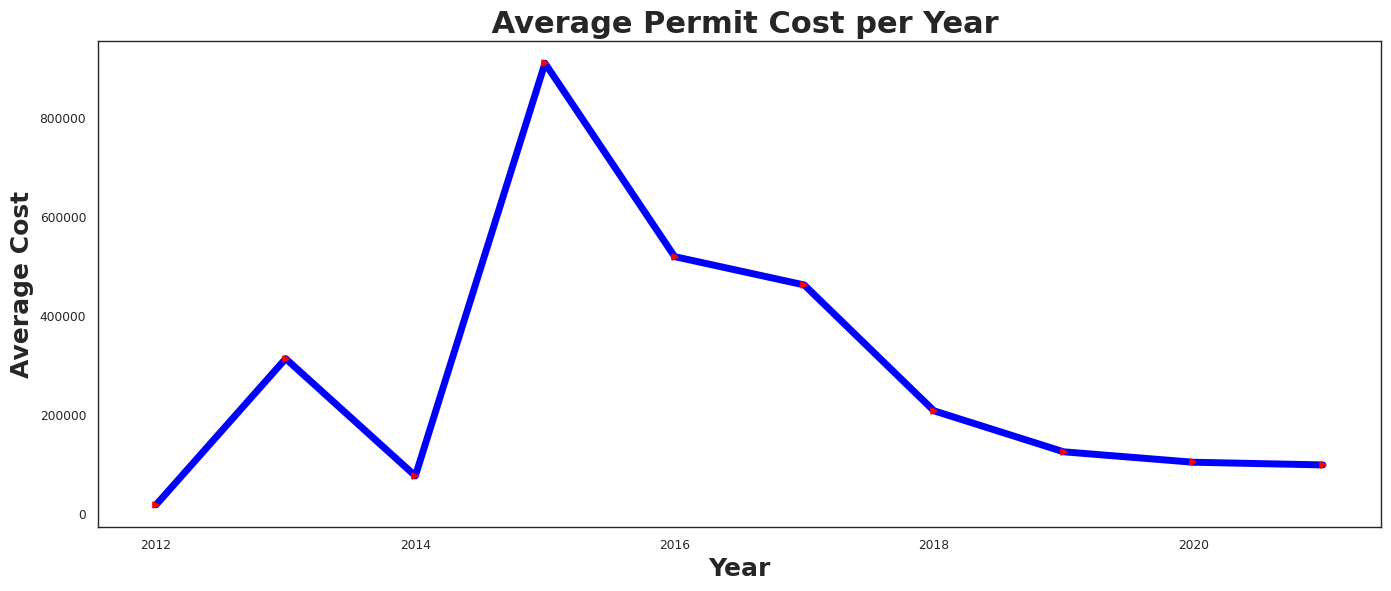

In [114]:
# Create Year column
df['Year'] = pd.to_datetime(df['IssuedDate']).dt.year

# Create average cost series
df['TotalCost'] = pd.to_numeric(df['TotalCost'], errors='coerce')
df = df.dropna(subset=['TotalCost'])
cost_year_mean = df.groupby('Year', as_index=False)['TotalCost'].mean().sort_values('Year')

# Plot average cost evolution
plt.figure(figsize=(14, 6))
sns.set_context("paper")
ax = sns.lineplot(data=cost_year_mean, x='Year', y='TotalCost', errorbar=None,
                  color='blue',markerfacecolor='red',markeredgecolor='red',
                  markeredgewidth=1.2, marker='>',linewidth=5)
ax.set_title(' Average Permit Cost per Year', fontsize=22, weight='bold')
ax.set_xlabel('Year', fontsize=18, weight='bold')
ax.set_ylabel('Average Cost', fontsize=18, weight='bold')
ax.grid(True, color='white')
plt.tight_layout()
plt.show()

### Comment:
* The line plot reveals a sharp spike in average permit cost in 2015, marking it the most expensive year in the dataset. It could a reflection a of large-scale construction projects that demanded more materials and labor.
* External factors such as rising material prices (inflation) or policy changes may affect permit cost in 2015
* The continuous cost decline suggests an improved cost efficiency in permitting processes.

<br></br>

### ARIMA Method

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency YS-JAN will be used.
  self._init_dates(dates, freq)


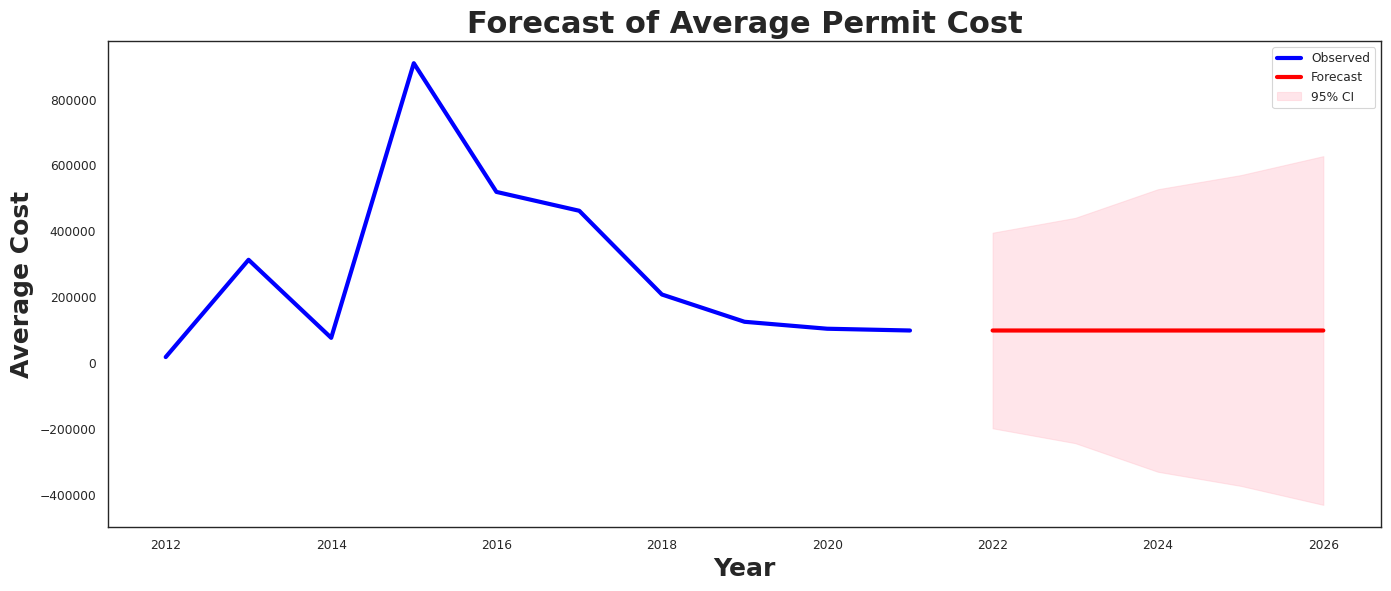

In [115]:
# Prepare the series
ts = cost_year_mean.copy()
ts["Year"] = pd.to_datetime(ts["Year"], format="%Y")
ts = ts.set_index("Year")["TotalCost"]

# Fit ARIMA model
model = sm.tsa.ARIMA(ts, order=(1,1,1))
results = model.fit()

# Forecast next 5 years
forecast = results.get_forecast(steps=5)
pred = forecast.predicted_mean
conf_int = forecast.conf_int()

# Plot
plt.figure(figsize=(14,6))
plt.plot(ts.index, ts, label="Observed", linewidth=3, color="blue")
plt.plot(pred.index, pred, label="Forecast", linewidth=3, color="red")

# Confidence interval shading
plt.fill_between(
    conf_int.index,
    conf_int.iloc[:,0],
    conf_int.iloc[:,1],
    color="pink",
    alpha=0.4,
    label="95% CI"
)

plt.title("Forecast of Average Permit Cost", fontsize=22, weight="bold")
plt.xlabel("Year", fontsize=18, weight="bold")
plt.ylabel("Average Cost", fontsize=18, weight="bold")
plt.grid(True, color="white")
plt.legend()
plt.tight_layout()
plt.show()


### Prophet Method

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:n_changepoints greater than number of observations. Using 7.
/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


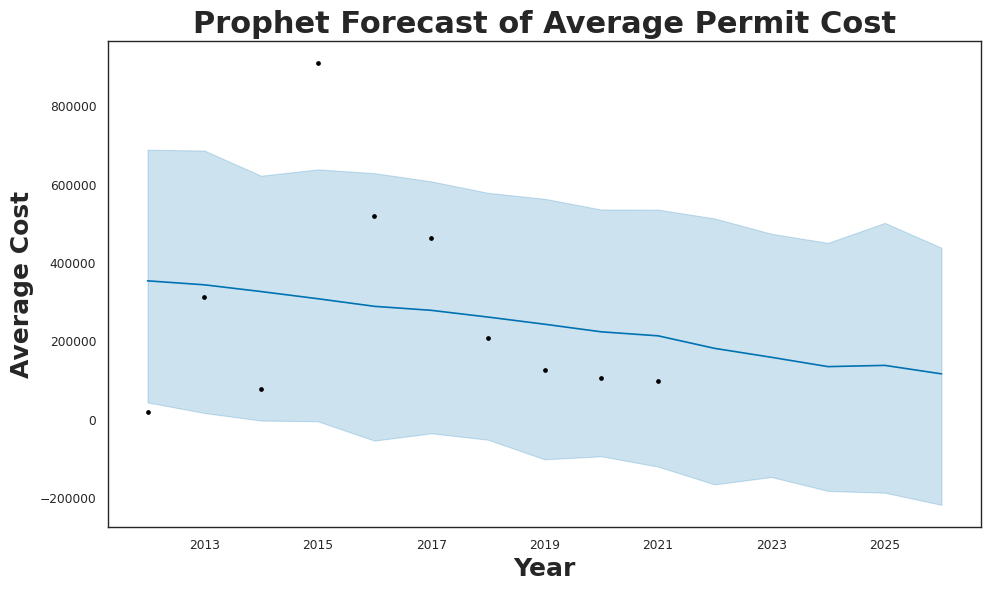

In [116]:
# Prepare Prophet dataframe
df_prophet = cost_year_mean.copy()
df_prophet["ds"] = pd.to_datetime(df_prophet["Year"], format="%Y")
df_prophet["y"] = df_prophet["TotalCost"]
df_prophet = df_prophet[["ds", "y"]]

# Fit model
m = Prophet()
m.fit(df_prophet)

# Forecast next 5 years
future = m.make_future_dataframe(periods=5, freq="Y")
forecast = m.predict(future)

# Plot
fig = m.plot(forecast)
plt.title("Prophet Forecast of Average Permit Cost", fontsize=22, weight="bold")
plt.xlabel("Year", fontsize=18, weight="bold")
plt.ylabel("Average Cost", fontsize=18, weight="bold")
plt.grid(True, color="white")
plt.tight_layout()
plt.show()


#### Comment:
* Both methods are in agreement of no strong upward trend in permit cost the next 5 years
* Both show decline from 2022 to 2026
* Both models show wider confidence intervals as time progress, meaning that future permit costs are volatile in Florida



---



# **Final Insights and Conclusions**

XGBoost achieved the strongest performance in classifying permits as Residential or Commercial, reaching about 95% accuracy and the highest recall for Commercial permits. This higher recall is valuable because it reduces the chance of missing true commercial projects, which typically require more complex review and stricter zoning compliance. While Logistic Regression and Random Forest provided useful baselines, XGBoost captured nonlinear interactions between zoning, permit categories, and project scale more effectively.

The cost‑forecasting analysis using both ARIMA and Prophet showed a stable to slightly declining trend in average permit costs through 2026, with both models producing consistent results and wide but reasonable uncertainty bands. This stability supports predictable budgeting and long‑term planning for developers and city officials.